# Stage 2 SA + Stage 3 CA — Results Inspector

Reads a run folder produced by `train_stage3_ca.py` (full pipeline from scratch):
- **Stage 2 (SA):** single-attention AB-MIL, encoder frozen — this becomes the frozen SA in Stage 3.
- **Stage 3 (CA):** cross-attention layer added on top of frozen SA + frozen encoder + frozen classifier.

Sections:
1. Cytokine groups (bootstrap sample)
2. Run log
3. Saved figures (Stage 2 learning curves, Stage 3 learning curves, SA vs CA entropy, CA weight norm)
4. Load dynamics (both stages)
5. Stage 2 SA training: loss-curve proxy + learnability ranking
6. Stage 3 CA-only: loss, CA weight norm, learnability ranking
7. Stage 2 vs Stage 3 rank comparison
8. Hypothesis test (Stage 3 rankings)
9. Confusion entropy (Stage 3)
10. SA vs CA attention entropy per cytokine (Stage 3)
11. Cell-type confidence trajectories (SA = Stage 2 final state; CA = Stage 3 trained)


In [1]:
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
from IPython.display import Image, display, Markdown
from scipy.stats import mannwhitneyu, spearmanr

import anndata as ad
from cytokine_mil.analysis.dynamics import (
    aggregate_to_donor_level,
    rank_cytokines_by_learnability,
    compute_confusion_entropy_summary,
)

In [2]:
_results_root = Path("/cs/labs/mornitzan/yam.arieli/cytokines/cytokines-mil/scripts/results")
_available = sorted([p.name for p in _results_root.iterdir()
                      if p.is_dir() and p.name.startswith("stage3_ca_seed")])\
             if _results_root.exists() else []
_available

['stage3_ca_seed42_20260326_194415_pid491786',
 'stage3_ca_seed42_20260326_213650_pid548536',
 'stage3_ca_seed42_20260327_140341_pid1259686']

In [3]:
# ============================================================
# SET THIS — name of the folder inside results/
# e.g. "stage3_ca_seed42_20260325_120000_pid12345"
# ============================================================
RESULTS_FOLDER = _available[-1] if _available else ""

# ============================================================

def _load_run(folder_name: str) -> Path:
    if not folder_name:
        print("Set RESULTS_FOLDER to one of:", _available)
        raise ValueError("RESULTS_FOLDER is empty")
    p = _results_root / folder_name
    if not p.exists():
        raise FileNotFoundError(f"Not found: {p}")
    return p

run_dir = _load_run(RESULTS_FOLDER)
print(f"Inspecting: {run_dir}")

Inspecting: /cs/labs/mornitzan/yam.arieli/cytokines/cytokines-mil/scripts/results/stage3_ca_seed42_20260327_140341_pid1259686


## 1. Cytokine Groups

In [4]:
with open(run_dir / "cytokine_groups.json") as f:
    groups = json.load(f)

simple   = groups["simple_cytokines"]
complex_ = groups["complex_cytokines"]
seed     = groups.get("bootstrap_seed", "(not stored)")

# Infer seed from folder name if not in json
import re
_m = re.search(r"stage3_ca_seed(\d+)", RESULTS_FOLDER)
if _m:
    seed = int(_m.group(1))

display(Markdown(f"""
**Bootstrap seed:** `{seed}`

| Group | Cytokines |
|-------|----------|
| SIMPLE | {', '.join(simple)} |
| COMPLEX | {', '.join(complex_)} |
"""))


**Bootstrap seed:** `42`

| Group | Cytokines |
|-------|----------|
| SIMPLE | G-CSF, IL-1-beta, IL-10, IL-2, IL-4 |
| COMPLEX | HGF, IL-12, IL-22, IL-32-beta, VEGF |


## 2. Run Log

In [5]:
print((run_dir / "run_log.txt").read_text())

Full CA-only experiment — seed=42  n_sample=5
Output directory: /cs/labs/mornitzan/yam.arieli/cytokines/cytokines-mil/scripts/results/stage3_ca_seed42_20260327_140341_pid1259686
Started: 20260327_140341_pid1259686

Device:         cuda
Bootstrap seed: 42  (controls cytokine sampling)
Training seed:  42   (controls model initialization)

Full manifest entries: 10920
HVGs: 4000
Sampled simple  (5): ['G-CSF', 'IL-1-beta', 'IL-10', 'IL-2', 'IL-4']
Sampled complex (5): ['HGF', 'IL-12', 'IL-22', 'IL-32-beta', 'VEGF']
Full subset     (10): ['G-CSF', 'IL-1-beta', 'IL-10', 'IL-2', 'IL-4', 'HGF', 'IL-12', 'IL-22', 'IL-32-beta', 'VEGF']

Subset manifest entries: 1320
Classes: 91  (PBS at index 90)
Train donors: ['Donor1', 'Donor10', 'Donor11', 'Donor12', 'Donor4', 'Donor5', 'Donor6', 'Donor7', 'Donor8', 'Donor9']  (1100 tubes)
Val donors:   ['Donor2', 'Donor3']  (220 tubes)
Preloading tube datasets...
Train tubes: 1100
Val tubes:   220
Cells: 4825  |  Cell types: 18

Stage 1 — Encoder pre-trainin

## 3. Saved Figures

### 3.1 Stage 2 (SA) Learning Curves

Single-attention AB-MIL training. SA learns to attend to relevant cells.

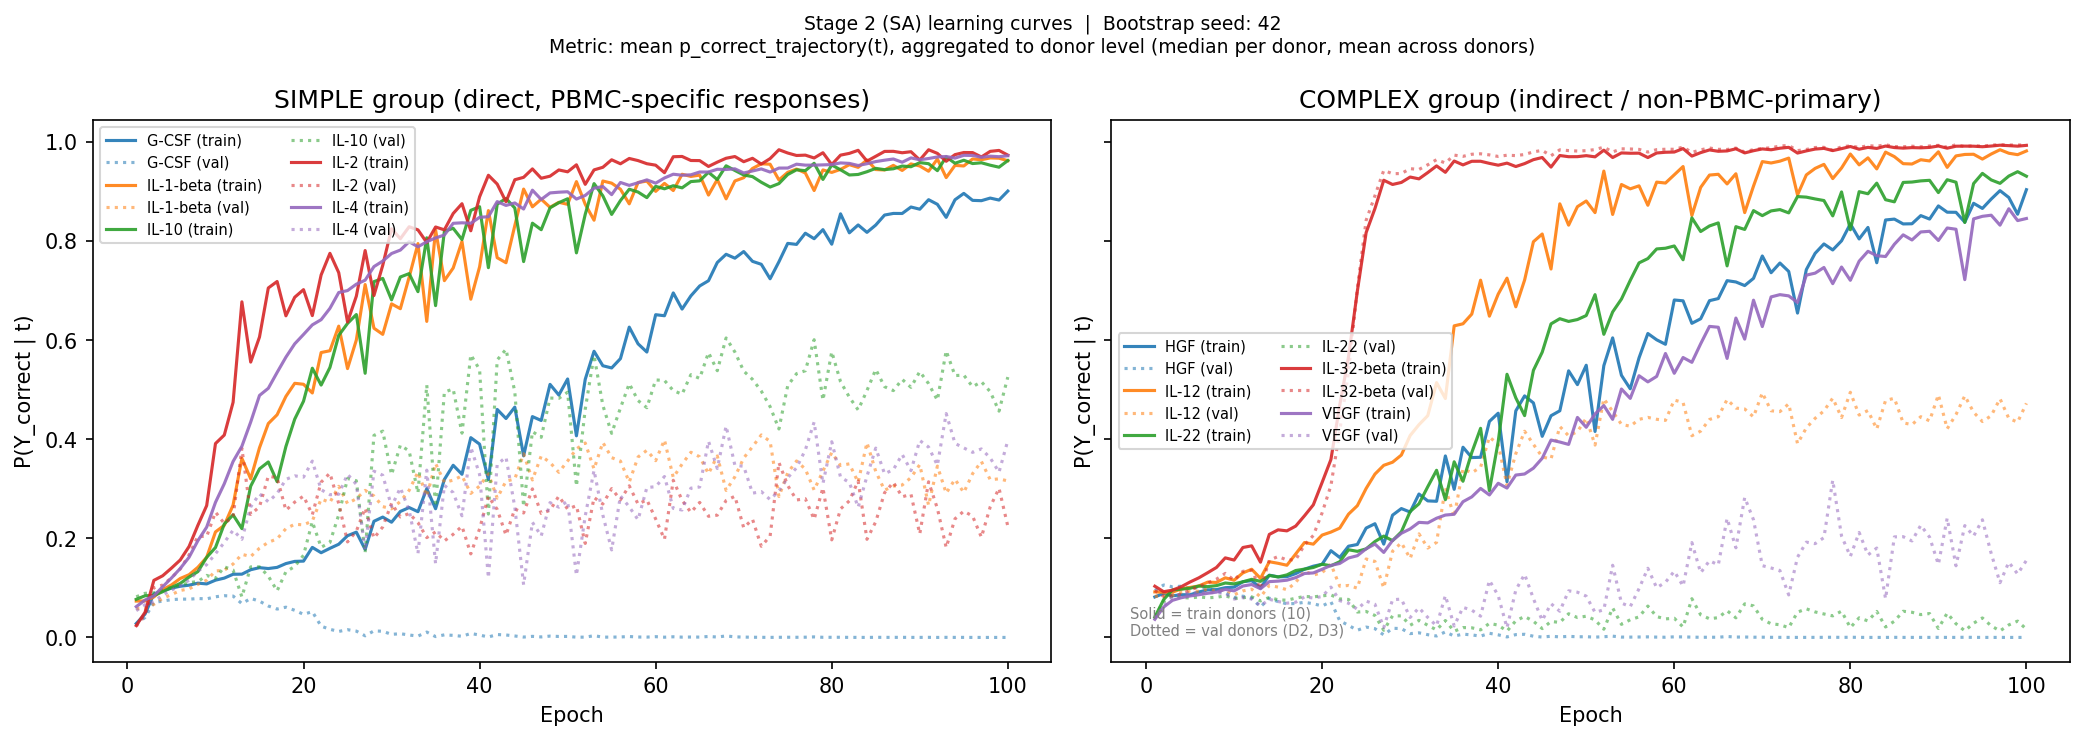

In [6]:
lc2_path = run_dir / f"learning_curves_stage2_{seed}.png"
if lc2_path.exists():
    display(Image(str(lc2_path)))
else:
    print(f"Not found: {lc2_path.name}")

### 3.2 Stage 3 (CA-only) Learning Curves

CA added on top of frozen SA. Shows what the CA layer learns **after** SA is already trained.

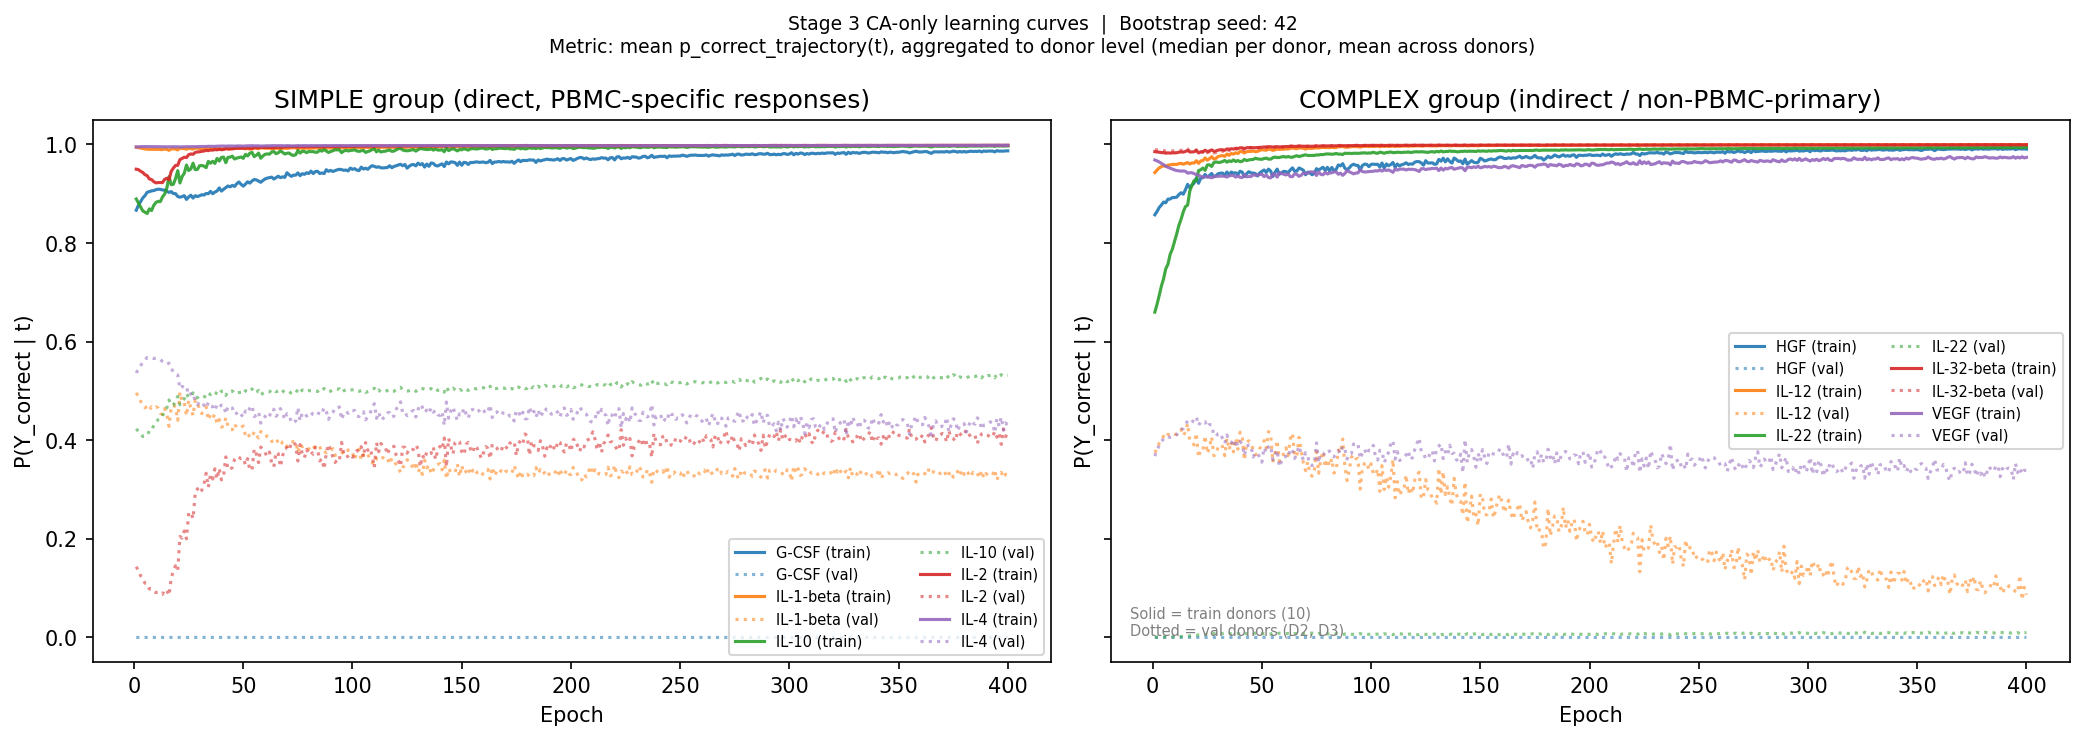

In [7]:
lc3_path = run_dir / f"learning_curves_stage3_ca_{seed}.png"
if lc3_path.exists():
    display(Image(str(lc3_path)))
else:
    print(f"Not found: {lc3_path.name}")

### 3.3 SA vs CA Attention Entropy (Stage 3 epochs)

**SA (blue, solid):** frozen during Stage 3 — entropy should be **constant** across Stage 3 epochs (sanity check).  
**CA (orange, dashed):** trainable — decreasing entropy means CA focuses on specific cells.

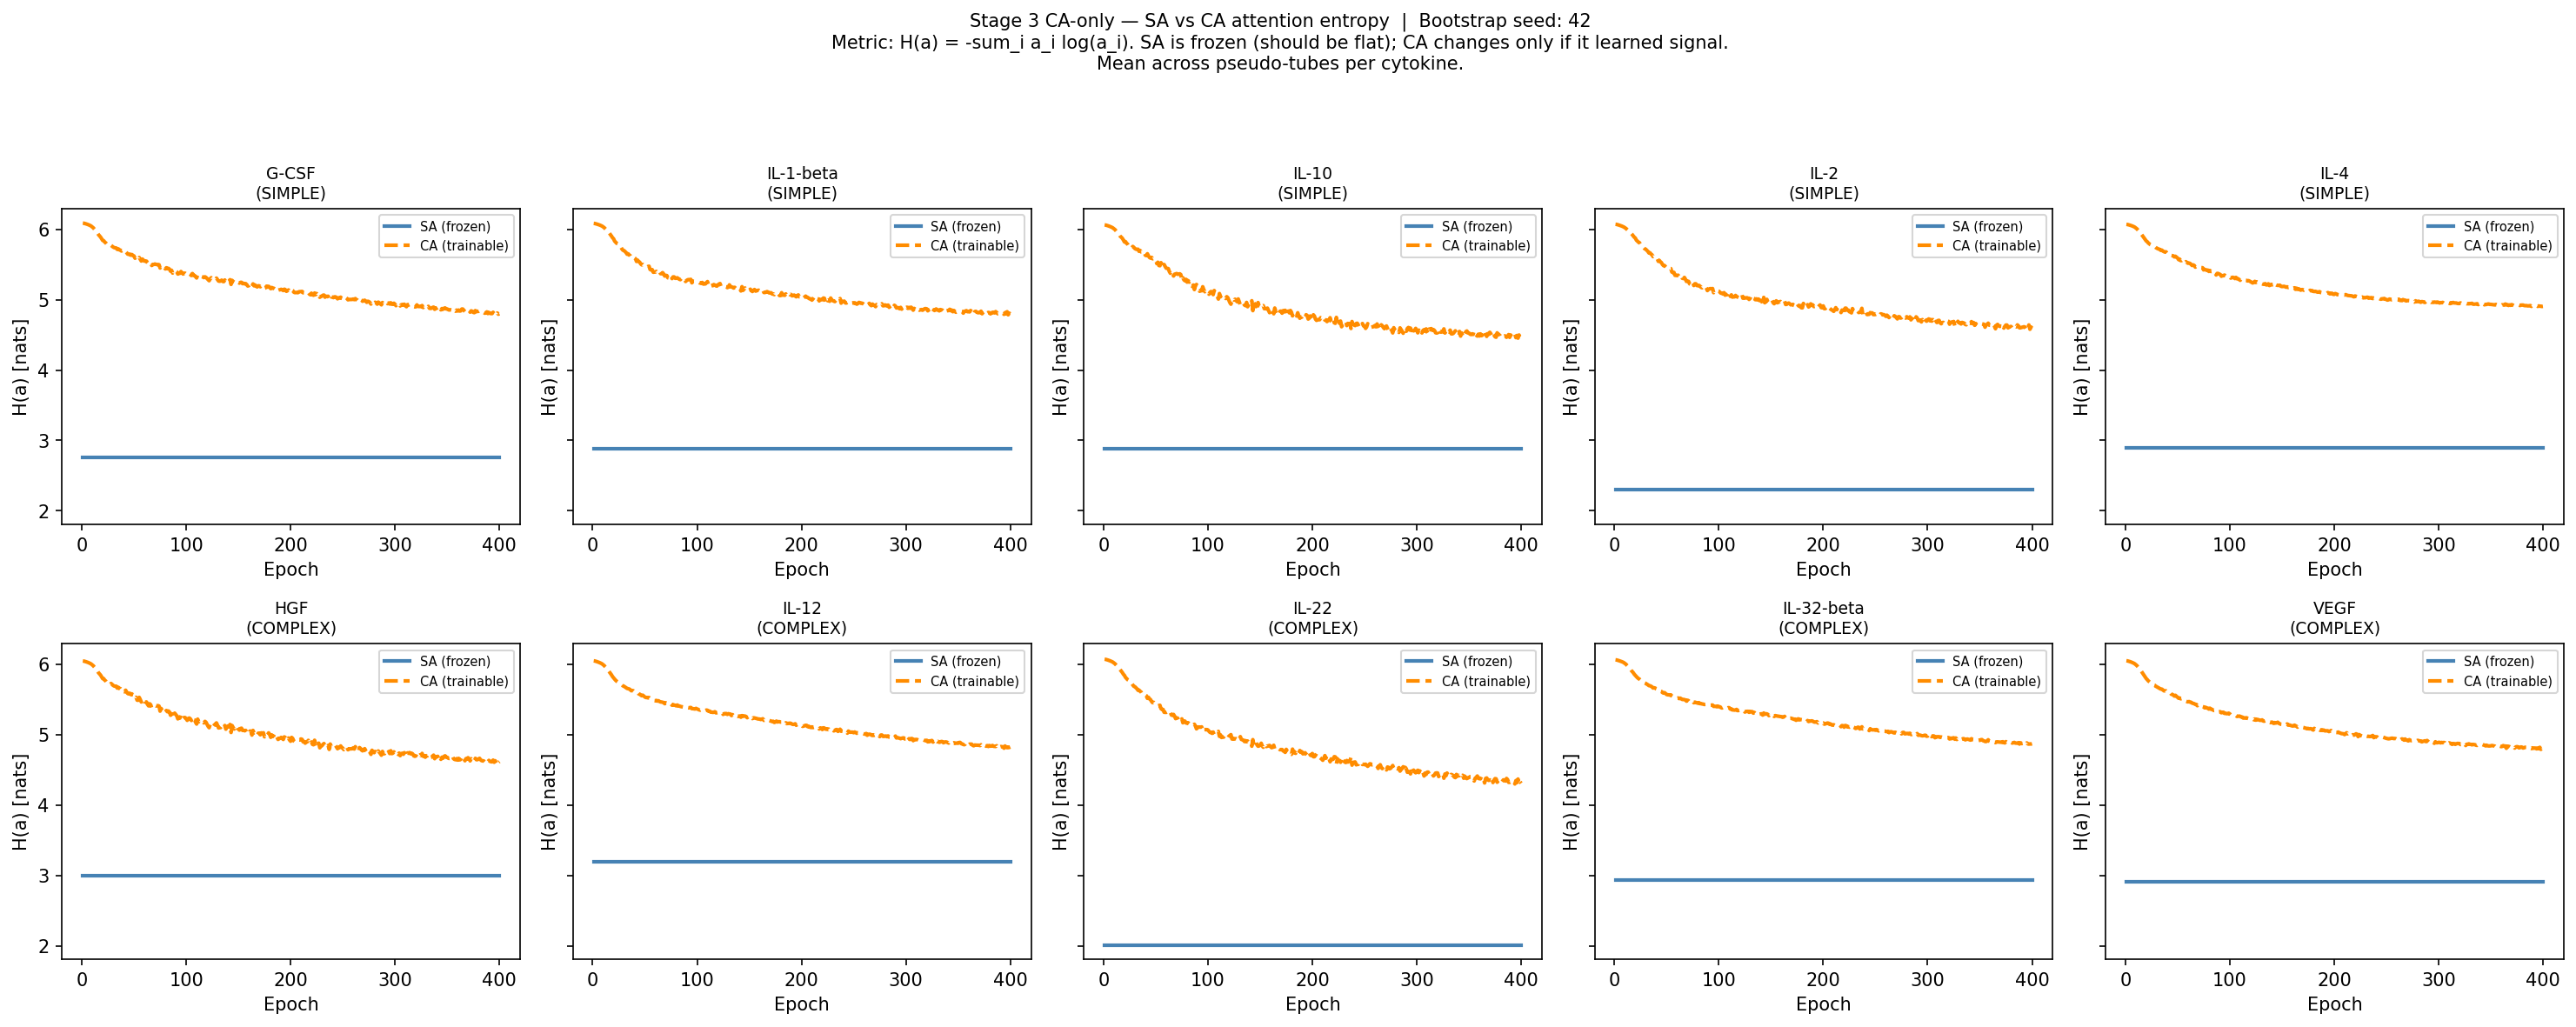

In [8]:
ent_path = run_dir / f"sa_vs_ca_entropy_stage3_ca_{seed}.png"
if ent_path.exists():
    display(Image(str(ent_path)))
else:
    print(f"Not found: {ent_path.name}")

### 3.4 CA Weight Norm Trajectory (Stage 3 epochs)

**Null hypothesis:** norm stays near initial value — CA contributes nothing.  
**Alternative:** norm grows — CA learned genuine additional signal beyond SA.

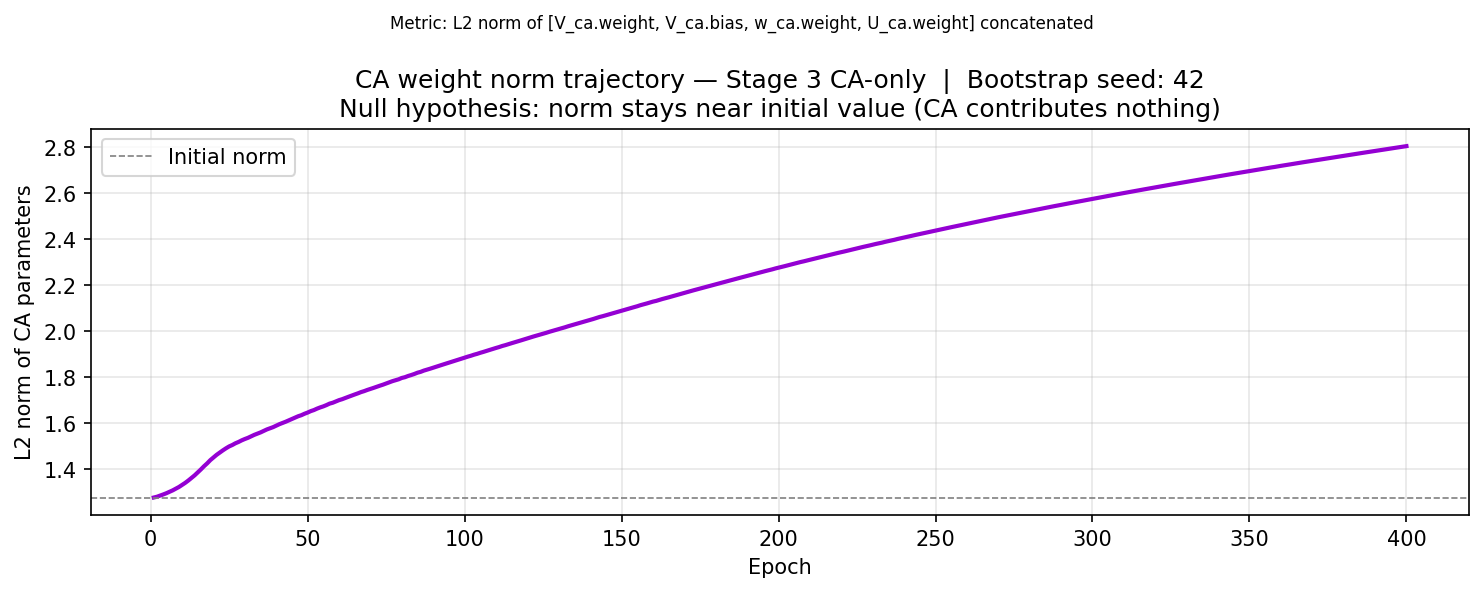

In [9]:
norm_path = run_dir / f"ca_weight_norm_stage3_ca_{seed}.png"
if norm_path.exists():
    display(Image(str(norm_path)))
else:
    print(f"Not found: {norm_path.name}")

## 4. Load Dynamics (Both Stages)

In [10]:
# Stage 2 — SA single-attention training
with open(run_dir / "dynamics_stage2.pkl", "rb") as fh:
    dyn2 = pickle.load(fh)

train_records2 = dyn2["records"]
val_records2   = dyn2["val_records"]
logged_epochs2 = dyn2["logged_epochs"]

print(f"Stage 2 — Train records: {len(train_records2)}")
print(f"Stage 2 — Val records  : {len(val_records2)}")
print(f"Stage 2 — Logged epochs: {len(logged_epochs2)}  "
      f"(first={logged_epochs2[0]}, last={logged_epochs2[-1]})")
print()

# Stage 3 — CA-only training
with open(run_dir / "dynamics_stage3.pkl", "rb") as fh:
    dyn3 = pickle.load(fh)

train_records3 = dyn3["records"]
val_records3   = dyn3["val_records"]
logged_epochs3 = dyn3["logged_epochs"]
ca_norm_traj   = dyn3["ca_weight_norm_trajectory"]
loss_traj      = dyn3["loss_trajectory"]
conf_ent_train = dyn3["confusion_entropy_trajectory"]
conf_ent_val   = dyn3["val_confusion_entropy_trajectory"]

print(f"Stage 3 — Train records: {len(train_records3)}")
print(f"Stage 3 — Val records  : {len(val_records3)}")
print(f"Stage 3 — Logged epochs: {len(logged_epochs3)}  "
      f"(first={logged_epochs3[0]}, last={logged_epochs3[-1]})")
print(f"Stage 3 — CA norm traj : {len(ca_norm_traj)} pts  "
      f"init={ca_norm_traj[0]:.6f}  final={ca_norm_traj[-1]:.6f}")

# Sanity check: SA entropy must be flat in Stage 3 (frozen)
sa_trajs = [r["entropy_trajectory"] for r in train_records3
            if r.get("entropy_trajectory")]
if sa_trajs:
    sa_var = float(np.var(np.concatenate(sa_trajs)))
    status = "OK" if sa_var < 1e-6 else "WARNING — SA is not frozen!"
    print(f"Stage 3 — SA entropy variance: {sa_var:.2e}  [{status}]")

Stage 2 — Train records: 1100
Stage 2 — Val records  : 220
Stage 2 — Logged epochs: 100  (first=1, last=100)

Stage 3 — Train records: 1100
Stage 3 — Val records  : 220
Stage 3 — Logged epochs: 400  (first=1, last=400)
Stage 3 — CA norm traj : 400 pts  init=1.277581  final=2.805852
Stage 3 — SA entropy variance: 5.08e-01  [WARNING — SA is not frozen!]


## 5. Stage 2 (SA) — Learnability Ranking

Learnability of the single-attention model. This is the baseline: what SA alone can learn.

In [11]:
donor_traj2     = aggregate_to_donor_level(train_records2)
val_donor_traj2 = aggregate_to_donor_level(val_records2)

learn2     = rank_cytokines_by_learnability(donor_traj2,     exclude=["PBS"])
val_learn2 = rank_cytokines_by_learnability(val_donor_traj2, exclude=["PBS"])
ranking2   = learn2["ranking"]
val_auc2   = {cyt: auc for cyt, auc in val_learn2["ranking"]}

print(f"Cytokine learnability ranking — Stage 2 SA  |  seed={seed}")
print(f"Metric: {learn2['metric_description']}")
print()
print(f"{'Rank':>4}  {'Cytokine':<16}  {'Train AUC':>9}  {'Val AUC':>8}  Group")
print("-" * 58)
for i, (cyt, auc) in enumerate(ranking2, 1):
    grp     = "SIMPLE" if cyt in simple else "COMPLEX"
    val_auc = val_auc2.get(cyt, float("nan"))
    print(f"  {i:2d}.  {cyt:<16}  {auc:>9.3f}  {val_auc:>8.3f}  {grp}")

s2_simple_aucs  = [auc for cyt, auc in ranking2 if cyt in simple]
s2_complex_aucs = [auc for cyt, auc in ranking2 if cyt in complex_]
print()
print(f"SIMPLE  mean={np.mean(s2_simple_aucs):.3f}  median={np.median(s2_simple_aucs):.3f}")
print(f"COMPLEX mean={np.mean(s2_complex_aucs):.3f}  median={np.median(s2_complex_aucs):.3f}")

Cytokine learnability ranking — Stage 2 SA  |  seed=42
Metric: AUC of mean p_correct_trajectory across pseudo-tubes, aggregated to donor level (median across pseudo-tubes per donor, then mean across donors)

Rank  Cytokine          Train AUC   Val AUC  Group
----------------------------------------------------------
   1.  IL-2                 80.553    24.358  SIMPLE
   2.  IL-32-beta           78.674    78.421  COMPLEX
   3.  IL-4                 76.945    28.053  SIMPLE
   4.  IL-1-beta            73.093    28.863  SIMPLE
   5.  IL-10                72.677    38.993  SIMPLE
   6.  IL-12                65.914    32.443  COMPLEX
   7.  IL-22                55.113     4.551  COMPLEX
   8.  G-CSF                49.309     1.615  SIMPLE
   9.  HGF                  49.181     1.979  COMPLEX
  10.  VEGF                 44.137    11.600  COMPLEX

SIMPLE  mean=70.515  median=73.093
COMPLEX mean=58.604  median=55.113


## 6. Stage 3 (CA-only) — Loss & CA Norm Trajectories

CA training starts from epoch 1. SA is frozen throughout.

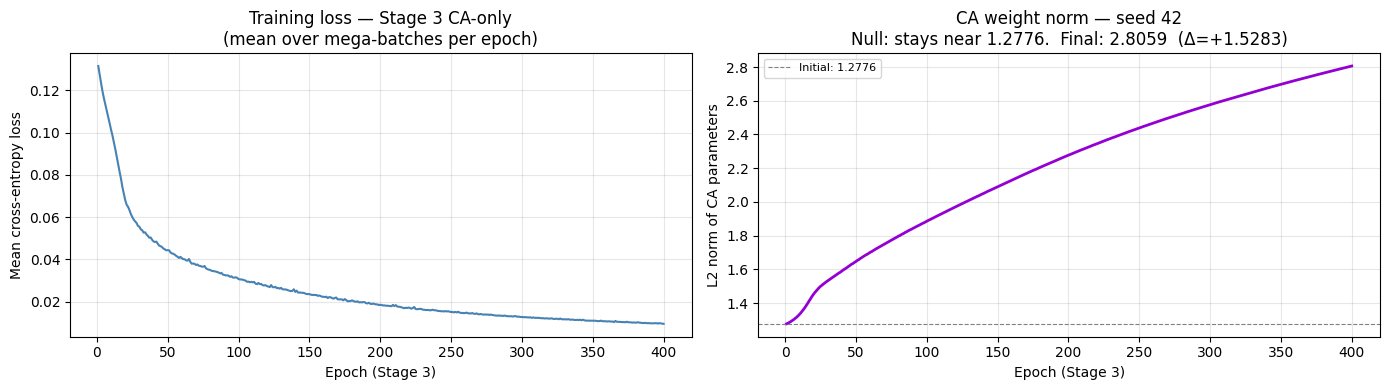

In [12]:
epochs_all = list(range(1, len(loss_traj) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_all, loss_traj, color="steelblue", lw=1.5)
axes[0].set_xlabel("Epoch (Stage 3)")
axes[0].set_ylabel("Mean cross-entropy loss")
axes[0].set_title("Training loss — Stage 3 CA-only\n(mean over mega-batches per epoch)")
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_all, ca_norm_traj, color="darkviolet", lw=2)
axes[1].axhline(ca_norm_traj[0], color="gray", ls="--", lw=0.8,
                label=f"Initial: {ca_norm_traj[0]:.4f}")
axes[1].set_xlabel("Epoch (Stage 3)")
axes[1].set_ylabel("L2 norm of CA parameters")
axes[1].set_title(
    f"CA weight norm — seed {seed}\n"
    f"Null: stays near {ca_norm_traj[0]:.4f}.  "
    f"Final: {ca_norm_traj[-1]:.4f}  (Δ={ca_norm_traj[-1]-ca_norm_traj[0]:+.4f})"
)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Stage 3 (CA-only) — Learnability Ranking

Learnability after CA training. Compare with Stage 2 ranking to see whether CA re-ordered cytokines.

In [13]:
donor_traj3     = aggregate_to_donor_level(train_records3)
val_donor_traj3 = aggregate_to_donor_level(val_records3)

learn3     = rank_cytokines_by_learnability(donor_traj3,     exclude=["PBS"])
val_learn3 = rank_cytokines_by_learnability(val_donor_traj3, exclude=["PBS"])
ranking3   = learn3["ranking"]
val_auc3   = {cyt: auc for cyt, auc in val_learn3["ranking"]}

print(f"Cytokine learnability ranking — Stage 3 CA-only  |  seed={seed}")
print(f"Metric: {learn3['metric_description']}")
print()
print(f"{'Rank':>4}  {'Cytokine':<16}  {'Train AUC':>9}  {'Val AUC':>8}  Group")
print("-" * 58)
for i, (cyt, auc) in enumerate(ranking3, 1):
    grp     = "SIMPLE" if cyt in simple else "COMPLEX"
    val_auc = val_auc3.get(cyt, float("nan"))
    print(f"  {i:2d}.  {cyt:<16}  {auc:>9.3f}  {val_auc:>8.3f}  {grp}")

s3_simple_aucs  = [auc for cyt, auc in ranking3 if cyt in simple]
s3_complex_aucs = [auc for cyt, auc in ranking3 if cyt in complex_]
print()
print(f"SIMPLE  mean={np.mean(s3_simple_aucs):.3f}  median={np.median(s3_simple_aucs):.3f}")
print(f"COMPLEX mean={np.mean(s3_complex_aucs):.3f}  median={np.median(s3_complex_aucs):.3f}")

Cytokine learnability ranking — Stage 3 CA-only  |  seed=42
Metric: AUC of mean p_correct_trajectory across pseudo-tubes, aggregated to donor level (median across pseudo-tubes per donor, then mean across donors)

Rank  Cytokine          Train AUC   Val AUC  Group
----------------------------------------------------------
   1.  IL-4                397.977   180.970  SIMPLE
   2.  IL-32-beta          397.911   397.988  COMPLEX
   3.  IL-1-beta           397.159   142.829  SIMPLE
   4.  IL-12               396.786    93.033  COMPLEX
   5.  IL-2                396.393   148.456  SIMPLE
   6.  IL-10               393.034   202.836  SIMPLE
   7.  IL-22               390.188     2.943  COMPLEX
   8.  HGF                 386.782     0.001  COMPLEX
   9.  G-CSF               383.271     0.003  SIMPLE
  10.  VEGF                382.068   145.267  COMPLEX

SIMPLE  mean=393.567  median=396.393
COMPLEX mean=390.747  median=390.188


## 8. Stage 2 vs Stage 3 Rank Comparison

If CA adds signal, it may re-order cytokines. High Spearman ρ means CA didn't change the ordering — 
it just sharpened or added noise. Low ρ means CA genuinely changed which cytokines are "learnable".

In [14]:
s2_order = [c for c, _ in ranking2]
s3_order = [c for c, _ in ranking3]

if set(s2_order) == set(s3_order):
    s3_rank_by = {c: i for i, c in enumerate(s3_order)}
    s3_aligned = [s3_rank_by[c] for c in s2_order]
    rho_stage, pval_stage = spearmanr(range(len(s2_order)), s3_aligned)

    auc2_map = {cyt: auc for cyt, auc in ranking2}
    auc3_map = {cyt: auc for cyt, auc in ranking3}

    print(f"Stage 2 vs Stage 3 rank correlation: Spearman ρ = {rho_stage:.3f}  (p={pval_stage:.3f})")
    print(f"Stable (ρ > 0.7): {rho_stage > 0.7}")
    print()
    print(f"{'Cytokine':<16}  {'S2 AUC':>8}  {'S2 Rank':>7}  {'S3 AUC':>8}  {'S3 Rank':>7}  "
          f"{'ΔAUC':>7}  {'ΔRank':>6}  Group")
    print("-" * 80)
    for cyt in s2_order:
        grp    = "SIMPLE" if cyt in simple else "COMPLEX"
        s2r    = s2_order.index(cyt) + 1
        s3r    = s3_order.index(cyt) + 1
        delta_auc  = auc3_map[cyt] - auc2_map[cyt]
        delta_rank = s3r - s2r
        arrow  = "↑" if delta_rank < 0 else ("↓" if delta_rank > 0 else "=")
        print(f"  {cyt:<16}  {auc2_map[cyt]:>8.3f}  {s2r:>7}  {auc3_map[cyt]:>8.3f}  "
              f"{s3r:>7}  {delta_auc:>+7.3f}  {arrow}{abs(delta_rank):>4}  {grp}")
else:
    print("Cytokine sets differ between Stage 2 and Stage 3 — cannot compare.")

Stage 2 vs Stage 3 rank correlation: Spearman ρ = 0.830  (p=0.003)
Stable (ρ > 0.7): True

Cytokine            S2 AUC  S2 Rank    S3 AUC  S3 Rank     ΔAUC   ΔRank  Group
--------------------------------------------------------------------------------
  IL-2                80.553        1   396.393        5  +315.840  ↓   4  SIMPLE
  IL-32-beta          78.674        2   397.911        2  +319.237  =   0  COMPLEX
  IL-4                76.945        3   397.977        1  +321.032  ↑   2  SIMPLE
  IL-1-beta           73.093        4   397.159        3  +324.067  ↑   1  SIMPLE
  IL-10               72.677        5   393.034        6  +320.356  ↓   1  SIMPLE
  IL-12               65.914        6   396.786        4  +330.872  ↑   2  COMPLEX
  IL-22               55.113        7   390.188        7  +335.075  =   0  COMPLEX
  G-CSF               49.309        8   383.271        9  +333.962  ↓   1  SIMPLE
  HGF                 49.181        9   386.782        8  +337.601  ↑   1  COMPLEX
  VEGF 

## 9. Hypothesis Test (Stage 3 CA-only)

In [15]:
auc_map          = {cyt: auc for cyt, auc in ranking3}
simple_auc_vals  = [auc_map[c] for c in simple  if c in auc_map]
complex_auc_vals = [auc_map[c] for c in complex_ if c in auc_map]

if simple_auc_vals and complex_auc_vals:
    u_stat, p_one_sided = mannwhitneyu(simple_auc_vals, complex_auc_vals, alternative="greater")
    n1, n2 = len(simple_auc_vals), len(complex_auc_vals)
    r_rb   = 1 - (2 * u_stat) / (n1 * n2)
    supported = p_one_sided < 0.05
    verdict   = "**SUPPORTED** (p < 0.05)" if supported else "**NOT SUPPORTED** (p ≥ 0.05)"

    train_order = [c for c, _ in ranking3]
    val_order   = [c for c, _ in val_learn3["ranking"]]
    val_rank_by = {c: i for i, c in enumerate(val_order)}
    val_aligned = [val_rank_by.get(c, len(val_order)) for c in train_order]
    rho_gen, pval_gen = spearmanr(range(len(train_order)), val_aligned)

    display(Markdown(f"""
**Hypothesis:** SIMPLE cytokines rank higher in learnability AUC than COMPLEX.  
**Test:** one-sided Mann-Whitney U (train donors only, Stage 3 CA-only rankings).

| | Value |
|---|---|
| SIMPLE AUCs | {', '.join(f'{x:.3f}' for x in sorted(simple_auc_vals, reverse=True))} |
| COMPLEX AUCs | {', '.join(f'{x:.3f}' for x in sorted(complex_auc_vals, reverse=True))} |
| Mann-Whitney U | {u_stat:.1f} |
| p-value (one-sided) | {p_one_sided:.4f} |
| rank-biserial r | {r_rb:.3f} |
| **Verdict** | {verdict} |
| Train/val rank Spearman ρ | {rho_gen:.3f} (p={pval_gen:.3f}) |
| Stable (ρ > 0.7) | {rho_gen > 0.7} |
"""))
else:
    print("Not enough cytokines in one or both groups to run test.")


**Hypothesis:** SIMPLE cytokines rank higher in learnability AUC than COMPLEX.  
**Test:** one-sided Mann-Whitney U (train donors only, Stage 3 CA-only rankings).

| | Value |
|---|---|
| SIMPLE AUCs | 397.977, 397.159, 396.393, 393.034, 383.271 |
| COMPLEX AUCs | 397.911, 396.786, 390.188, 386.782, 382.068 |
| Mann-Whitney U | 16.0 |
| p-value (one-sided) | 0.2738 |
| rank-biserial r | -0.280 |
| **Verdict** | **NOT SUPPORTED** (p ≥ 0.05) |
| Train/val rank Spearman ρ | 0.576 (p=0.082) |
| Stable (ρ > 0.7) | False |


## 10. Confusion Entropy Ranking (Stage 3)

In [16]:
conf_result     = compute_confusion_entropy_summary(conf_ent_train, exclude=["PBS"])
val_conf_result = compute_confusion_entropy_summary(conf_ent_val,   exclude=["PBS"])
val_conf_map    = {cyt: auc for cyt, auc in val_conf_result["ranking"]}

print(f"Confusion entropy ranking — Stage 3 CA-only  |  seed={seed}")
print(f"Metric: {conf_result['metric_description']}")
print()
print(f"{'Cytokine':<20}  {'Train AUC(H_c)':>14}  {'Val AUC(H_c)':>12}  Group")
print("-" * 64)
for cyt, auc in conf_result["ranking"]:
    grp     = "SIMPLE" if cyt in simple else ("COMPLEX" if cyt in complex_ else "")
    val_auc = val_conf_map.get(cyt, float("nan"))
    print(f"  {cyt:<20}  {auc:>14.3f}  {val_auc:>12.3f}  {grp}")

Confusion entropy ranking — Stage 3 CA-only  |  seed=42
Metric: AUC of H_confusion(C,t) = -sum_{k!=C} q_k(t) * log(q_k(t)), where q_k(t) is the renormalized off-diagonal mean softmax score across all pseudo-tubes of cytokine C at epoch t. Low = confusion concentrated on similar cytokines (similarity confound). High = confusion spread randomly (genuine difficulty).

Cytokine              Train AUC(H_c)  Val AUC(H_c)  Group
----------------------------------------------------------------
  IL-1-beta                    607.021       302.709  SIMPLE
  VEGF                         538.507       463.673  COMPLEX
  IL-22                        515.321       534.397  COMPLEX
  IL-12                        505.459       457.557  COMPLEX
  IL-4                         475.122       443.518  SIMPLE
  G-CSF                        455.840       649.234  SIMPLE
  HGF                          420.712       535.251  COMPLEX
  IL-2                         407.650       323.782  SIMPLE
  IL-32-beta     

## 11. SA vs CA Attention Entropy per Cytokine (Stage 3 epochs)

**SA (blue):** frozen during Stage 3 — entropy should be a **flat horizontal line**.  
A non-zero SA Δ is a freezing bug.  
**CA (orange):** trainable — key metric. Decreasing = CA focusing on specific cells.

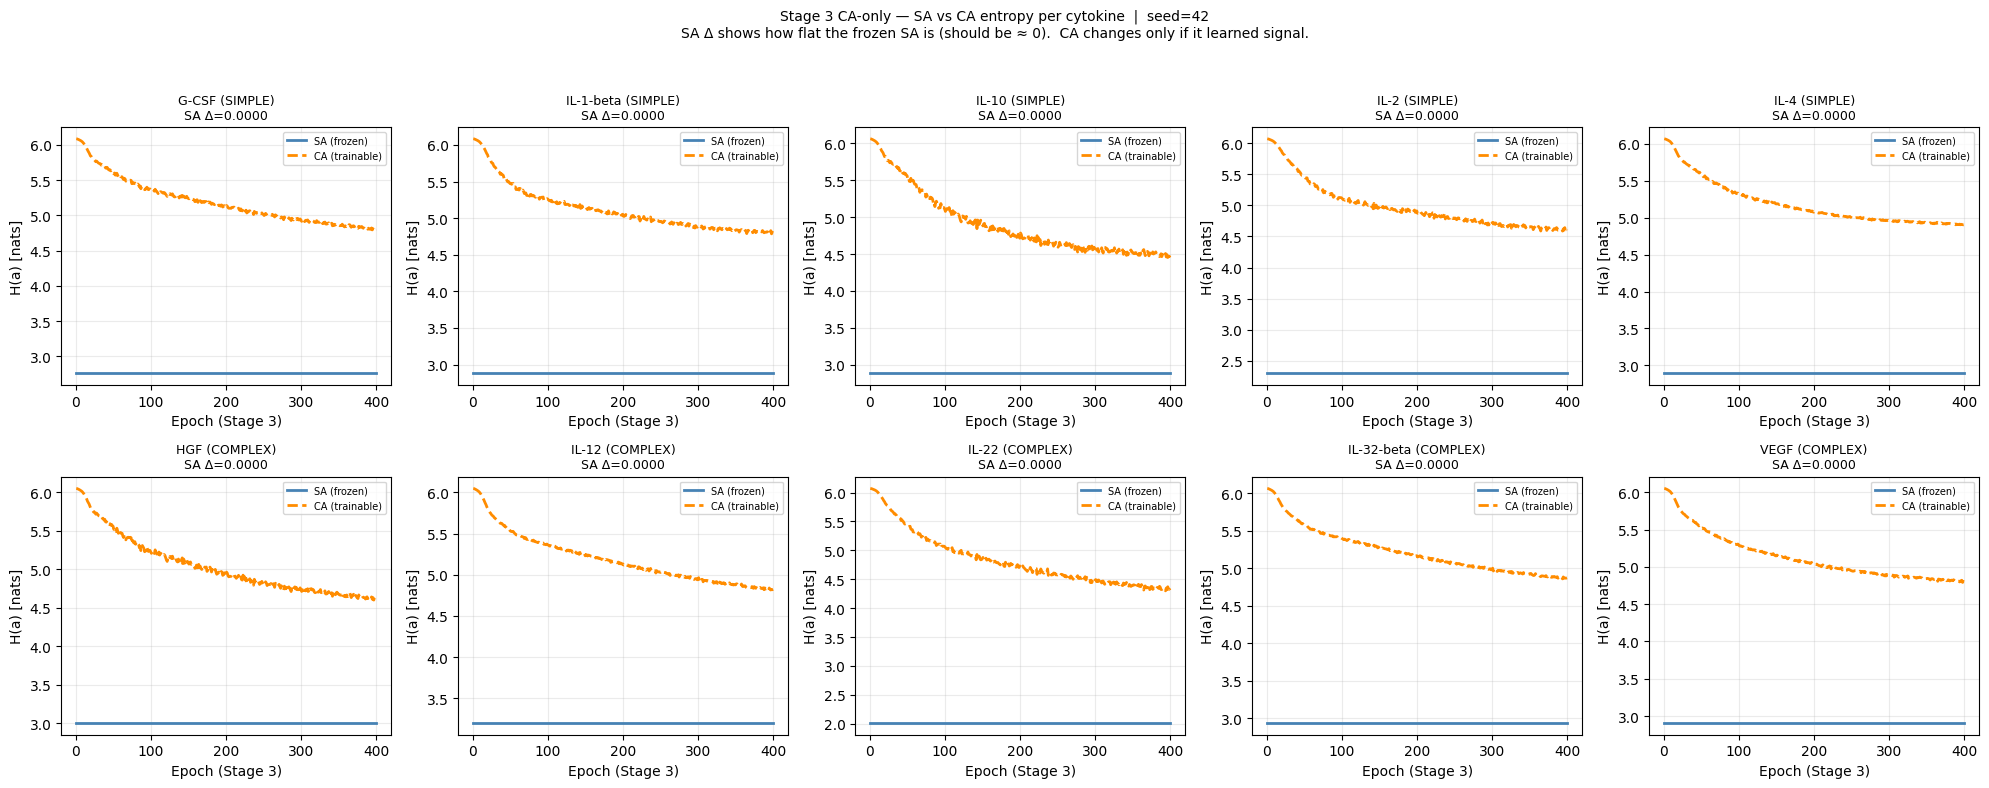

In [17]:
def _extract_layer_entropy(records, cytokine):
    sa_curves, ca_curves = [], []
    for rec in records:
        if rec["cytokine"] != cytokine:
            continue
        sa = rec.get("entropy_trajectory")
        ca = rec.get("entropy_trajectory_ca")
        if sa and ca:
            sa_curves.append(np.array(sa))
            ca_curves.append(np.array(ca))
    return sa_curves, ca_curves


all_cyts  = simple + complex_
group_map = {c: "SIMPLE" for c in simple}
group_map.update({c: "COMPLEX" for c in complex_})

n_cyts = len(all_cyts)
ncols  = 5
nrows  = (n_cyts + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), sharey=False)
axes = np.array(axes).flatten()

for ax, cyt in zip(axes, all_cyts):
    grp = group_map.get(cyt, "")
    sa_curves, ca_curves = _extract_layer_entropy(train_records3, cyt)
    if sa_curves:
        mean_sa = np.mean(sa_curves, axis=0)
        mean_ca = np.mean(ca_curves, axis=0)
        ax.plot(logged_epochs3, mean_sa, color="steelblue",  lw=2, label="SA (frozen)")
        ax.plot(logged_epochs3, mean_ca, color="darkorange", lw=2, ls="--", label="CA (trainable)")
        sa_range = float(max(mean_sa) - min(mean_sa))
        ax.set_title(f"{cyt} ({grp})\nSA Δ={sa_range:.4f}", fontsize=9)
    else:
        ax.set_title(f"{cyt} ({grp})\n[no data]", fontsize=9)
    ax.set_xlabel("Epoch (Stage 3)")
    ax.set_ylabel("H(a) [nats]")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

for ax in axes[n_cyts:]:
    ax.set_visible(False)

fig.suptitle(
    f"Stage 3 CA-only — SA vs CA entropy per cytokine  |  seed={seed}\n"
    "SA Δ shows how flat the frozen SA is (should be ≈ 0).  "
    "CA changes only if it learned signal.",
    fontsize=10,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 12. Cell-type Confidence Trajectories

Cell-type labels are **never** used during training — reintroduced post-hoc only.

- **SA panel** (`confidence_trajectory_sa` from Stage 3 records): SA is frozen in Stage 3, so this
  reflects the **final learned Stage 2 SA representation** — which cell types SA learned to attend to.
  The trajectory is flat (all epochs look the same) — what matters is the **level** per cell type.
- **CA panel** (`confidence_trajectory_ca` from Stage 3 records): what the newly trained CA layer
  discovered. Cell types high here but flat in SA are secondary cascade responders.

In [18]:
print("Loading cell type labels from pseudo-tube h5ad files (post-hoc only)...")
cell_type_obs = {}
for rec in train_records3 + val_records3:
    path = rec["tube_path"]
    if path not in cell_type_obs:
        _adata = ad.read_h5ad(path, backed="r")
        cell_type_obs[path] = _adata.obs["cell_type"].values.copy()
        _adata.file.close()

_all_cts = sorted({ct for labels in cell_type_obs.values() for ct in labels})
print(f"Cell types found ({len(_all_cts)}): {_all_cts}")

Loading cell type labels from pseudo-tube h5ad files (post-hoc only)...
Cell types found (18): ['B Intermediate/Memory', 'B Naive', 'CD14 Mono', 'CD16 Mono', 'CD4 Memory', 'CD4 Naive', 'CD8 Memory', 'CD8 Naive', 'HSPC', 'ILC', 'MAIT', 'NK', 'NK CD56bright', 'NKT', 'Plasmablast', 'Treg', 'cDC', 'pDC']


In [19]:
def _compute_ct_trajectories(records, cell_type_obs, cytokine, conf_key):
    """
    Compute mean C_i(t) per cell type for one cytokine.
    Aggregation: median across pseudo-tubes per donor, then mean across donors.
    """
    cyt_records = [r for r in records if r["cytokine"] == cytokine]
    if not cyt_records:
        return {}
    raw = defaultdict(lambda: defaultdict(list))
    for rec in cyt_records:
        conf = rec.get(conf_key)
        if conf is None:
            continue
        ct_labels = cell_type_obs.get(rec["tube_path"])
        if ct_labels is None:
            continue
        conf_arr = np.array(conf)  # (n_cells, n_logged_epochs)
        for ct in np.unique(ct_labels):
            mask = ct_labels == ct
            mean_traj = conf_arr[mask].mean(axis=0)
            raw[str(ct)][rec["donor"]].append(mean_traj)
    result = {}
    for ct, donors in raw.items():
        donor_trajs = [np.median(np.stack(trajs), axis=0) for trajs in donors.values()]
        result[ct] = np.mean(np.stack(donor_trajs), axis=0)
    return result


def _plot_ct_sa_vs_ca(records, cell_type_obs, cytokine, logged_epochs, group=""):
    sa_curves = _compute_ct_trajectories(records, cell_type_obs, cytokine,
                                         conf_key="confidence_trajectory_sa")
    ca_curves = _compute_ct_trajectories(records, cell_type_obs, cytokine,
                                         conf_key="confidence_trajectory_ca")
    if not sa_curves and not ca_curves:
        print(f"No confidence data for {cytokine}.")
        return

    all_cts   = sorted(set(sa_curves) | set(ca_curves))
    cmap      = plt.cm.tab20.colors
    ct_colors = {ct: cmap[i % len(cmap)] for i, ct in enumerate(all_cts)}

    y_max = max(
        max((t.max() for t in sa_curves.values()), default=0),
        max((t.max() for t in ca_curves.values()), default=0),
    ) * 1.05 or 0.1

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for ax, curves, layer_label in zip(
        axes,
        [sa_curves, ca_curves],
        ["SA layer (frozen — Stage 2 final state)",
         "CA layer (trainable — Stage 3)"],
    ):
        for ct in all_cts:
            if ct not in curves:
                continue
            ax.plot(logged_epochs, curves[ct], color=ct_colors[ct], lw=1.5, label=ct)
        ax.set_xlabel("Epoch (Stage 3)")
        ax.set_ylabel("Mean C_i(t)")
        ax.set_title(layer_label)
        ax.set_ylim(0, y_max)
        ax.legend(fontsize=7, ncol=2, loc="upper left")
        ax.grid(alpha=0.25)

    fig.suptitle(
        f"{cytokine}  [{group}] — SA vs CA cell-type confidence trajectories  |  seed={seed}\n"
        "SA: frozen (flat by design) — level reflects Stage 2 learned attention.  "
        "CA: trained in Stage 3.\n"
        "Metric: mean C_i(t) = a_i(t) * P(t)(Y_correct), grouped by cell type, "
        "aggregated to donor level (median per donor, mean across donors)",
        fontsize=9, y=1.02,
    )
    plt.tight_layout()
    plt.show()
    return sa_curves, ca_curves

### 12.1 SA vs CA Cell-type Confidence per Cytokine

- **SA left panel:** flat across Stage 3 epochs (frozen). The **level** of each cell type reveals
  what Stage 2 SA learned to attend to — these are the direct targets.
- **CA right panel:** what the newly trained CA layer discovered. Rising trajectories mean CA
  is learning to attend to those cell types during Stage 3 training.
- Cell types **prominent in CA but low in SA** = secondary cascade targets requiring contextual signal.

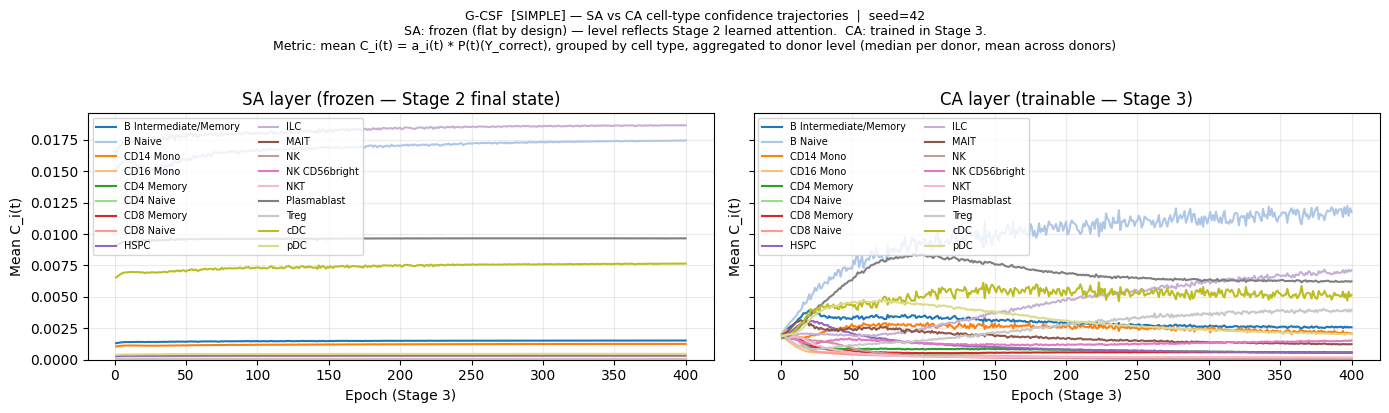

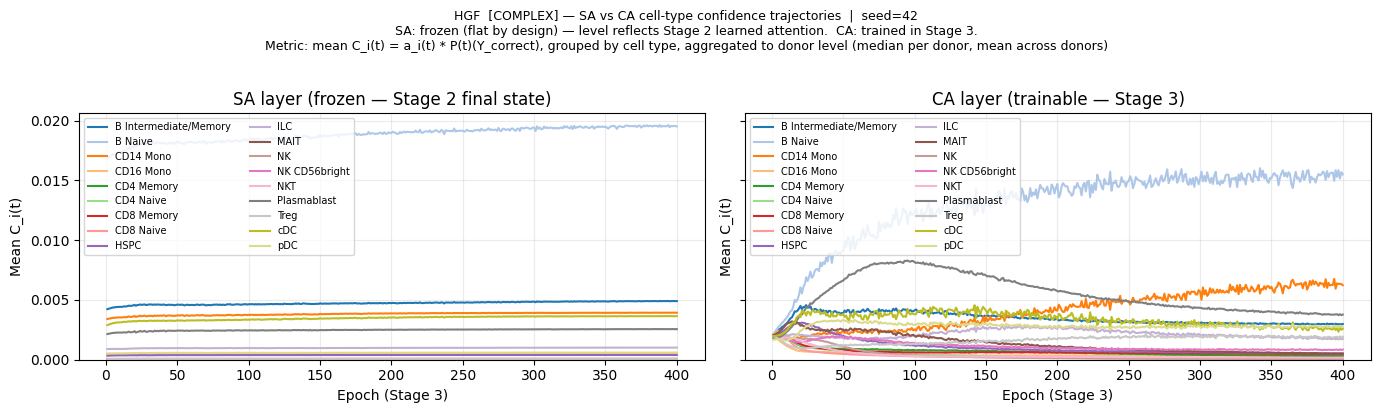

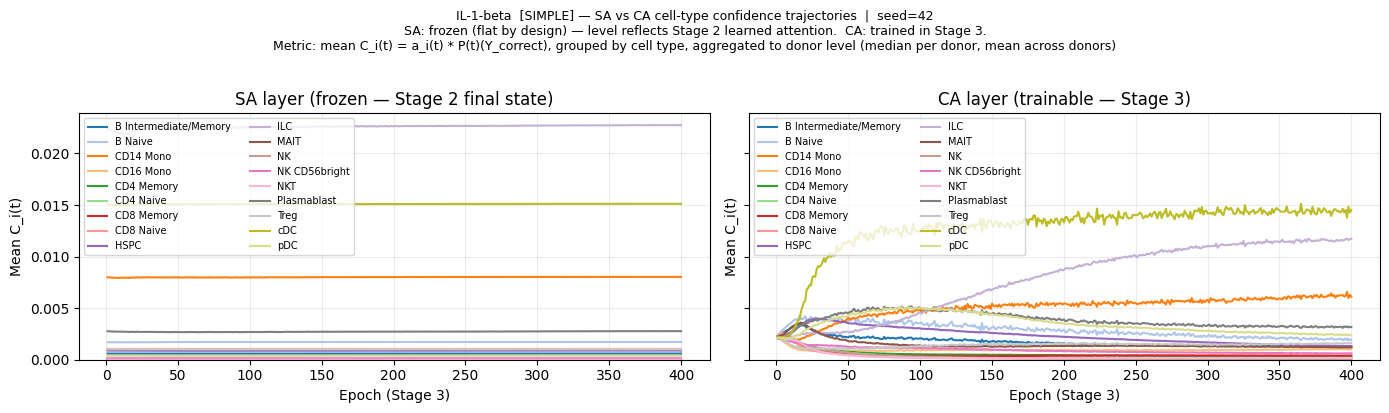

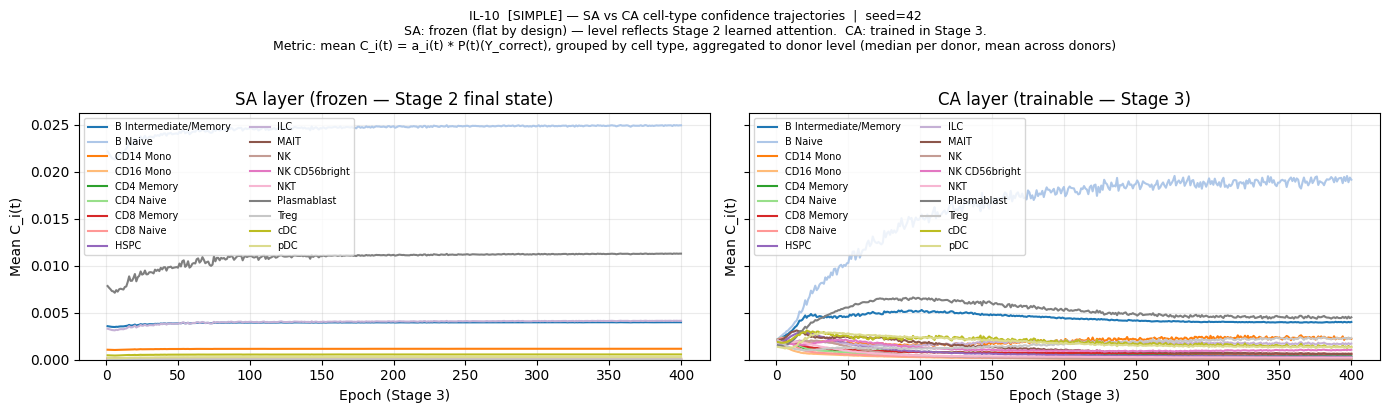

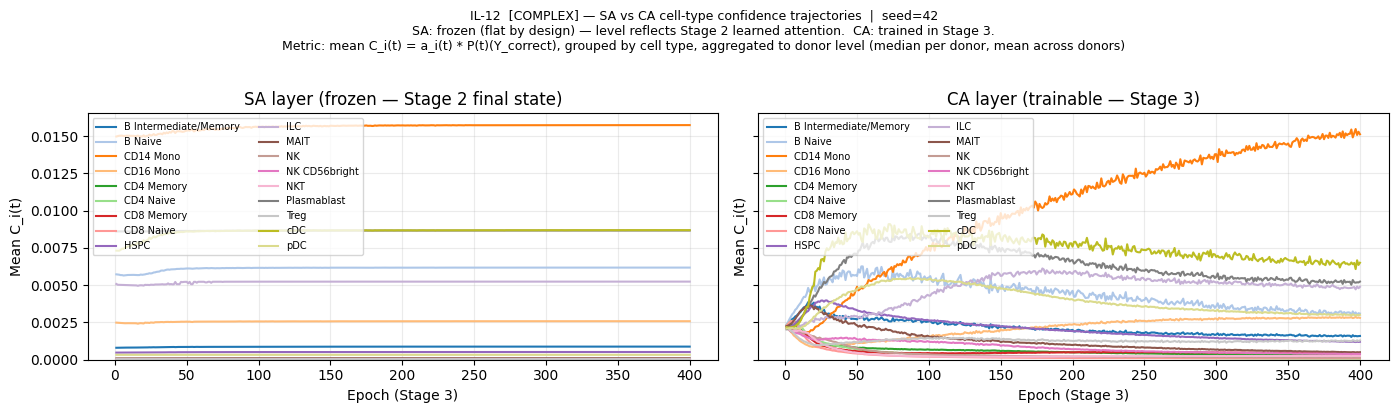

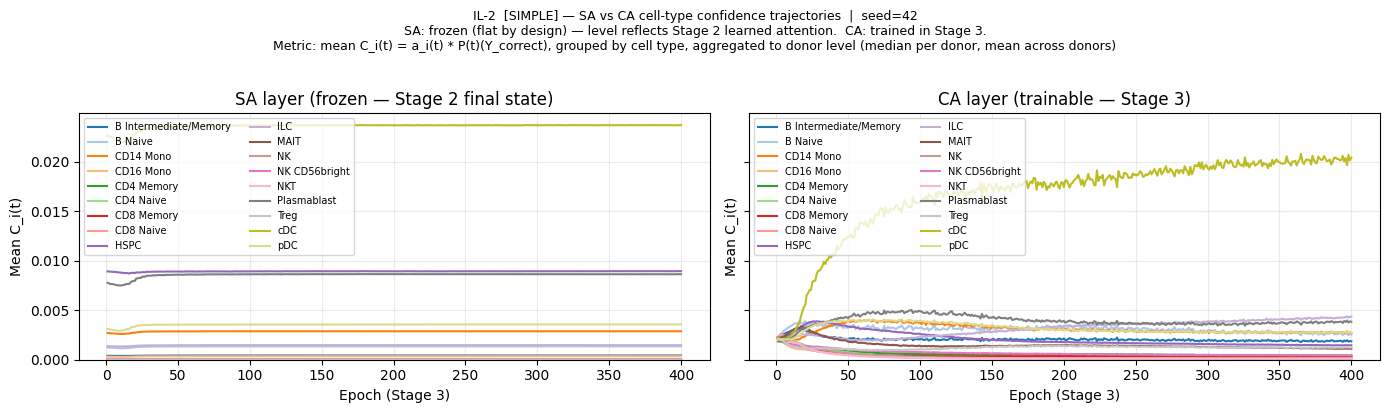

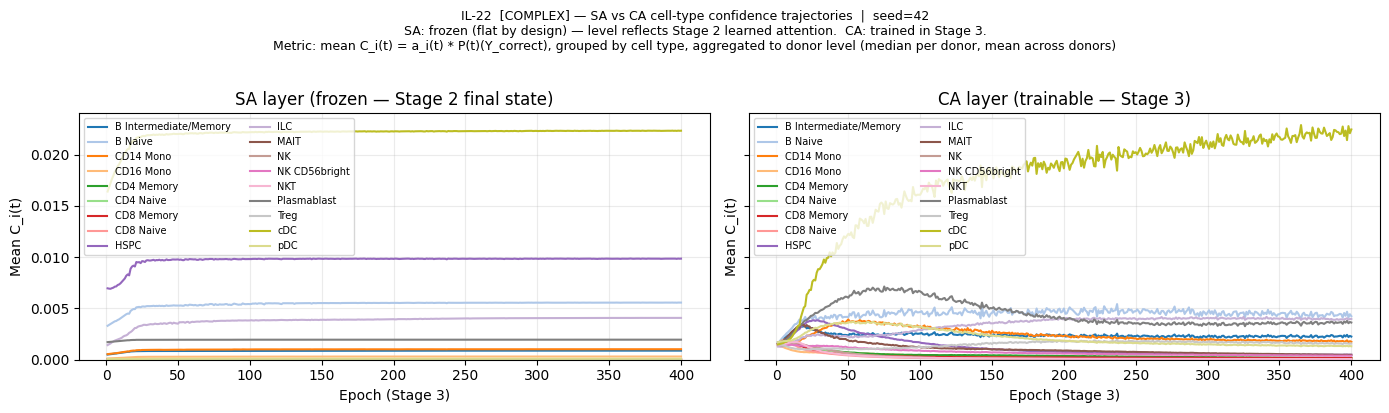

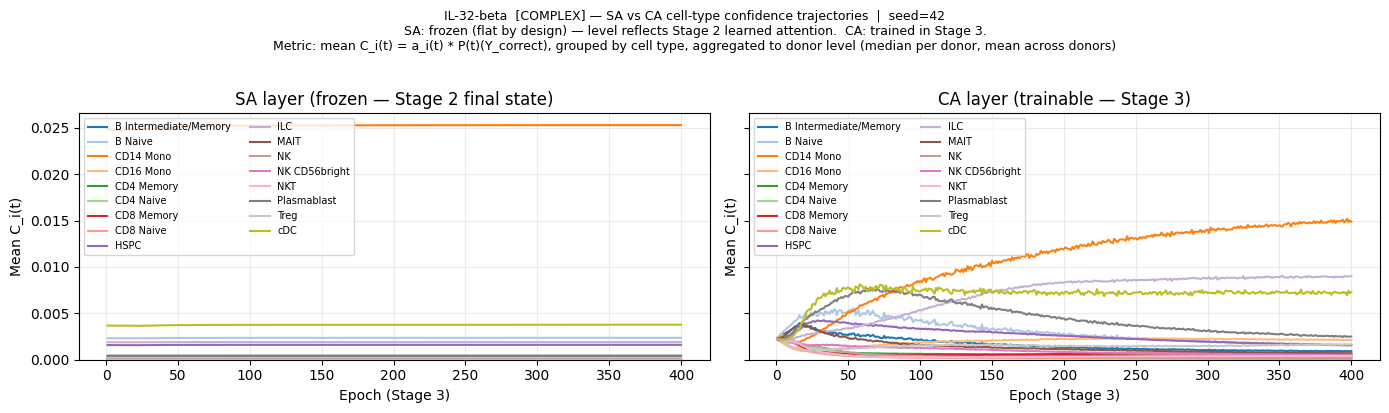

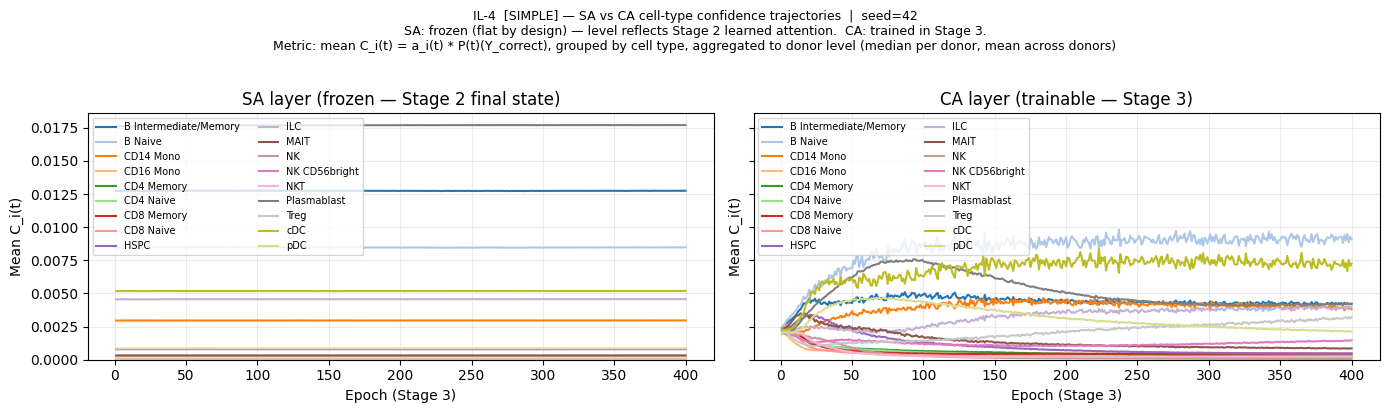

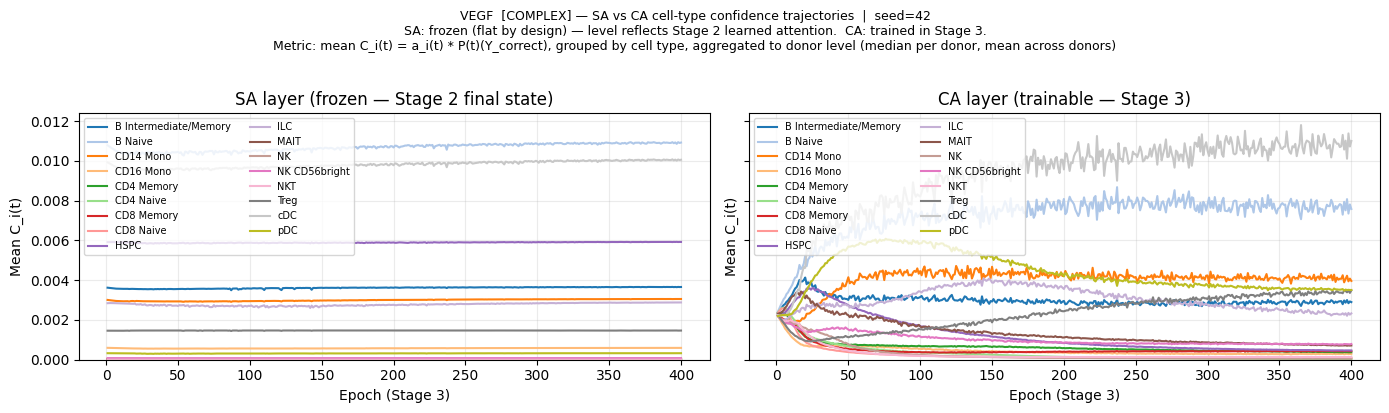

In [20]:
ct_results = {}
for cyt in sorted(simple + complex_):
    grp = "SIMPLE" if cyt in simple else "COMPLEX"
    result = _plot_ct_sa_vs_ca(train_records3, cell_type_obs, cyt, logged_epochs3, group=grp)
    if result is not None:
        ct_results[cyt] = {"sa": result[0], "ca": result[1]}

### 12.2 Cell-type Activation Heatmaps (SA vs CA)

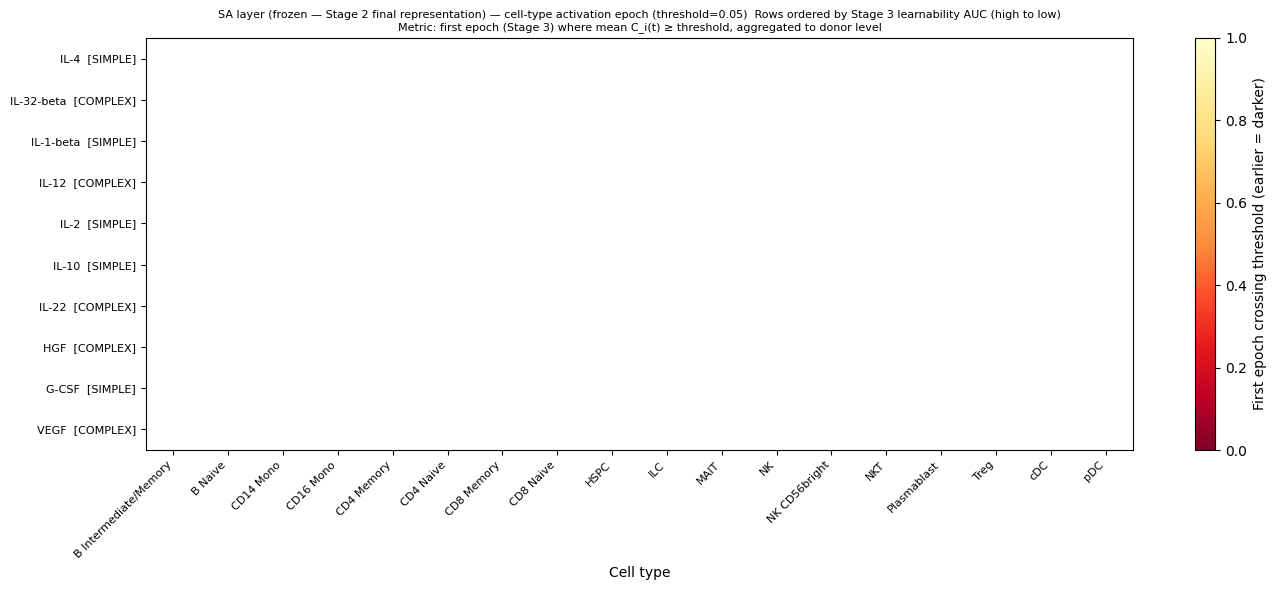

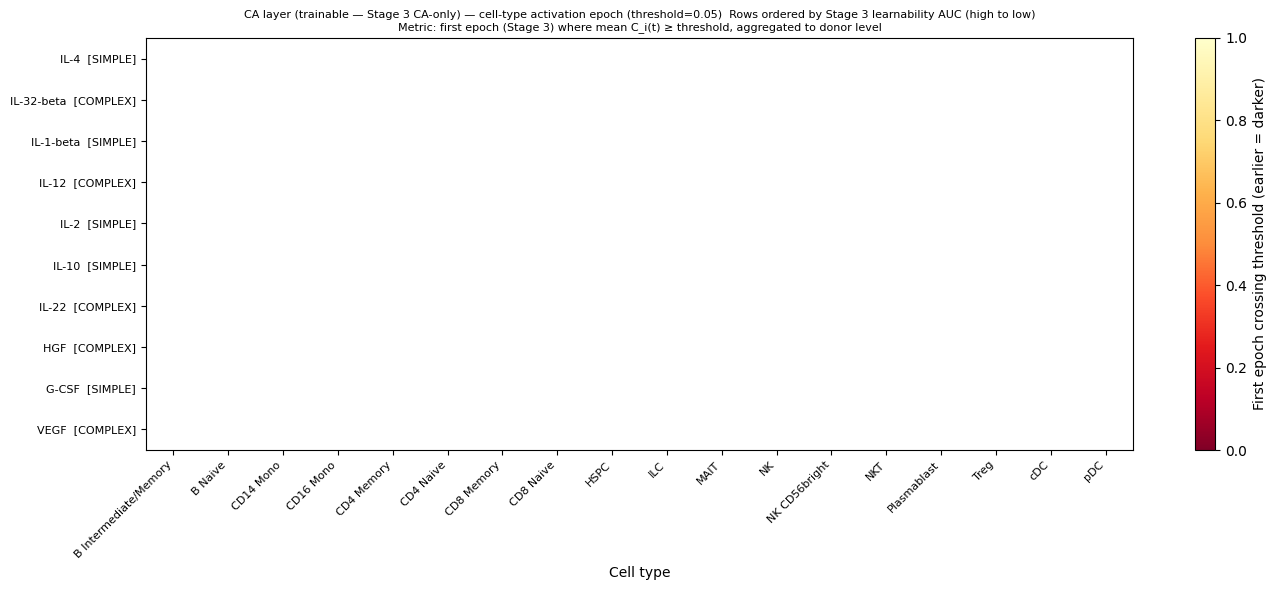

In [21]:
cyts_ranked = [c for c, _ in ranking3]

def _activation_epoch(ct_curves, threshold=0.05):
    result = {}
    for ct, traj in ct_curves.items():
        idx = np.where(np.asarray(traj) >= threshold)[0]
        result[ct] = int(idx[0]) if len(idx) > 0 else None
    return result


def _plot_activation_heatmap(records, cell_type_obs, cyts_ranked, logged_epochs,
                              simple_cyts, complex_cyts, conf_key, layer_label, threshold=0.05):
    all_ct = set()
    curves_by_cyt = {}
    for cyt in cyts_ranked:
        c = _compute_ct_trajectories(records, cell_type_obs, cyt, conf_key=conf_key)
        curves_by_cyt[cyt] = c
        all_ct.update(c.keys())
    all_ct = sorted(all_ct)

    act = {cyt: _activation_epoch(curves_by_cyt[cyt], threshold) for cyt in cyts_ranked}
    matrix = np.full((len(cyts_ranked), len(all_ct)), np.nan)
    for i, cyt in enumerate(cyts_ranked):
        for j, ct in enumerate(all_ct):
            ep_idx = act[cyt].get(ct)
            if ep_idx is not None:
                matrix[i, j] = logged_epochs[ep_idx]

    fig, ax = plt.subplots(figsize=(14, 6))
    vmin = np.nanmin(matrix) if not np.all(np.isnan(matrix)) else 0
    vmax = np.nanmax(matrix) if not np.all(np.isnan(matrix)) else 1
    im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd_r",
                   vmin=vmin, vmax=vmax, interpolation="nearest")
    plt.colorbar(im, ax=ax, label="First epoch crossing threshold (earlier = darker)")
    ax.set_xticks(range(len(all_ct)))
    ax.set_xticklabels(all_ct, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(cyts_ranked)))
    ylabels = []
    for cyt in cyts_ranked:
        if cyt in simple_cyts:    ylabels.append(f"{cyt}  [SIMPLE]")
        elif cyt in complex_cyts: ylabels.append(f"{cyt}  [COMPLEX]")
        else:                      ylabels.append(cyt)
    ax.set_yticklabels(ylabels, fontsize=8)
    ax.set_xlabel("Cell type")
    ax.set_title(
        f"{layer_label} — cell-type activation epoch (threshold={threshold})  "
        "Rows ordered by Stage 3 learnability AUC (high to low)\n"
        "Metric: first epoch (Stage 3) where mean C_i(t) ≥ threshold, aggregated to donor level",
        fontsize=8,
    )
    plt.tight_layout()
    plt.show()
    return act


act_sa = _plot_activation_heatmap(
    train_records3, cell_type_obs, cyts_ranked, logged_epochs3,
    simple, complex_, conf_key="confidence_trajectory_sa",
    layer_label="SA layer (frozen — Stage 2 final representation)",
)
act_ca = _plot_activation_heatmap(
    train_records3, cell_type_obs, cyts_ranked, logged_epochs3,
    simple, complex_, conf_key="confidence_trajectory_ca",
    layer_label="CA layer (trainable — Stage 3 CA-only)",
)

### 12.3 Cascade Ordering per Cytokine (SA vs CA)

In [22]:
print(f"Cell-type cascade ordering — SA vs CA  |  seed={seed}")
print("Metric: first Stage 3 epoch index where mean C_i(t) >= 0.05 per layer")
print("SA-only = direct targets (Stage 2 learned); CA-only = secondary cascade; both = hub")
print()

for cyt in cyts_ranked:
    grp = "SIMPLE" if cyt in simple else "COMPLEX"
    sa_act = act_sa.get(cyt, {})
    ca_act = act_ca.get(cyt, {})

    sa_activated = {ct for ct, ep in sa_act.items() if ep is not None}
    ca_activated = {ct for ct, ep in ca_act.items() if ep is not None}

    sa_only = sorted(sa_activated - ca_activated)
    ca_only = sorted(ca_activated - sa_activated)
    both    = sorted(sa_activated & ca_activated)

    print(f"{cyt:<20} [{grp}]")
    if sa_only: print(f"  SA-only (direct targets):       {sa_only}")
    if ca_only: print(f"  CA-only (cascade responders):   {ca_only}")
    if both:    print(f"  Both (hub cells):               {both}")
    if not sa_only and not ca_only and not both:
        print("  (no cell types crossed threshold)")
    print()

Cell-type cascade ordering — SA vs CA  |  seed=42
Metric: first Stage 3 epoch index where mean C_i(t) >= 0.05 per layer
SA-only = direct targets (Stage 2 learned); CA-only = secondary cascade; both = hub

IL-4                 [SIMPLE]
  (no cell types crossed threshold)

IL-32-beta           [COMPLEX]
  (no cell types crossed threshold)

IL-1-beta            [SIMPLE]
  (no cell types crossed threshold)

IL-12                [COMPLEX]
  (no cell types crossed threshold)

IL-2                 [SIMPLE]
  (no cell types crossed threshold)

IL-10                [SIMPLE]
  (no cell types crossed threshold)

IL-22                [COMPLEX]
  (no cell types crossed threshold)

HGF                  [COMPLEX]
  (no cell types crossed threshold)

G-CSF                [SIMPLE]
  (no cell types crossed threshold)

VEGF                 [COMPLEX]
  (no cell types crossed threshold)



## 13. Normalized AUC vs P_max Scatter

Each cytokine plotted as **shape** (normalized trajectory AUC) vs **ceiling** (P_max).  
Shown for Stage 2 (SA) and Stage 3 (CA-only) separately, train and val donors side by side.

- **Normalized AUC:** `AUC(p_correct(t) / max(p_correct(t)))`, trapz/(n−1) — captures learning *shape* independent of absolute confidence.
- **P_max:** `max(p_correct_trajectory)` — captures the *ceiling* reached.


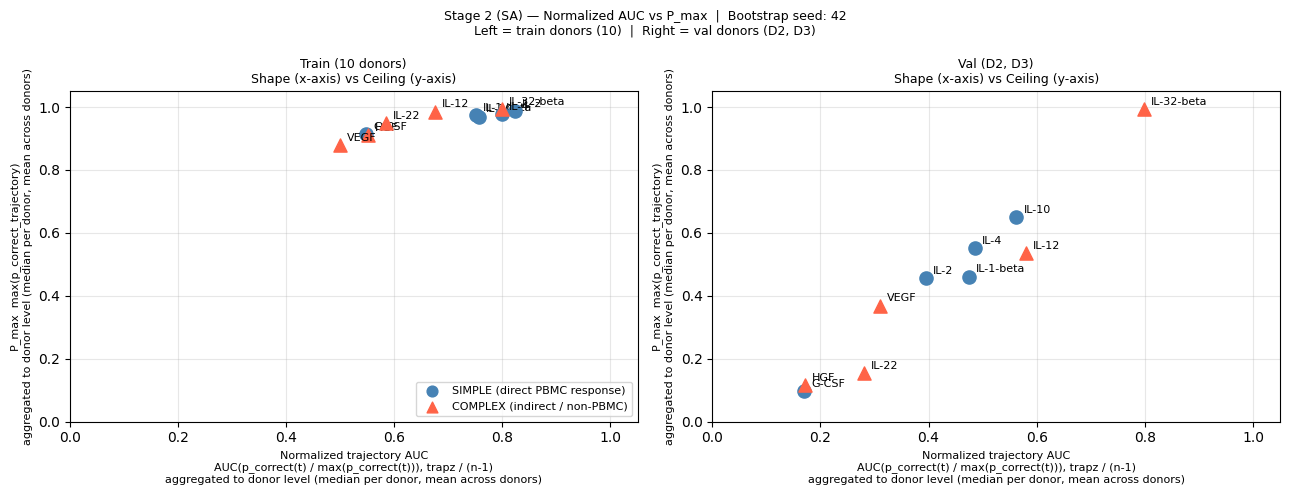

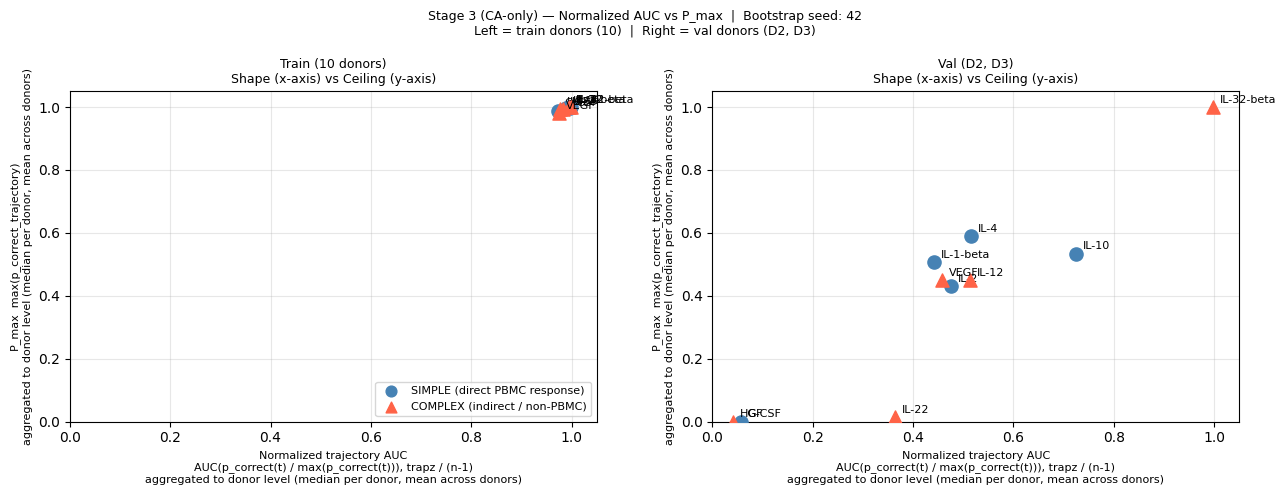

In [23]:
def _compute_normalized_auc(traj):
    arr = np.array(traj, dtype=float)
    max_val = arr.max()
    if max_val < 1e-10:
        return 0.0
    norm = arr / max_val
    return float(np.trapezoid(norm) / max(len(norm) - 1, 1))


def _aggregate_extra_metrics(records, exclude=("PBS",)):
    exclude_set = set(exclude)
    by_cyt_donor = {}
    for r in records:
        cyt = r["cytokine"]
        if cyt in exclude_set:
            continue
        by_cyt_donor.setdefault(cyt, {}).setdefault(r["donor"], []).append(r)
    result = {}
    for cyt, by_donor in by_cyt_donor.items():
        donor_norm_aucs, donor_pmaxes = [], []
        for recs in by_donor.values():
            donor_norm_aucs.append(float(np.median(
                [_compute_normalized_auc(r["p_correct_trajectory"]) for r in recs]
            )))
            donor_pmaxes.append(float(np.median(
                [float(np.max(r["p_correct_trajectory"])) for r in recs]
            )))
        result[cyt] = {
            "norm_auc": float(np.mean(donor_norm_aucs)),
            "pmax":     float(np.mean(donor_pmaxes)),
        }
    return result


def _plot_scatter(extra_train, extra_val, subset_cyts, simple_cyts, complex_cyts,
                  stage_label, seed):
    group_color  = {"SIMPLE": "steelblue", "COMPLEX": "tomato"}
    group_marker = {"SIMPLE": "o",         "COMPLEX": "^"}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, (split_label, extra_dict) in zip(axes, [
        ("Train (10 donors)", extra_train),
        ("Val (D2, D3)",      extra_val),
    ]):
        for cyt in subset_cyts:
            if cyt not in extra_dict:
                continue
            m     = extra_dict[cyt]
            group = "SIMPLE" if cyt in simple_cyts else "COMPLEX"
            ax.scatter(m["norm_auc"], m["pmax"],
                       color=group_color[group], marker=group_marker[group],
                       s=90, zorder=3)
            ax.annotate(cyt, (m["norm_auc"], m["pmax"]),
                        textcoords="offset points", xytext=(5, 3), fontsize=8)
        ax.set_xlabel(
            "Normalized trajectory AUC\n"
            "AUC(p_correct(t) / max(p_correct(t))), trapz / (n-1)\n"
            "aggregated to donor level (median per donor, mean across donors)",
            fontsize=8,
        )
        ax.set_ylabel(
            "P_max  max(p_correct_trajectory)\n"
            "aggregated to donor level (median per donor, mean across donors)",
            fontsize=8,
        )
        ax.set_title(f"{split_label}\nShape (x-axis) vs Ceiling (y-axis)", fontsize=9)
        ax.set_xlim(0, 1.05)
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)

    legend_handles = [
        plt.scatter([], [], color=group_color["SIMPLE"],  marker=group_marker["SIMPLE"],
                    s=60, label="SIMPLE (direct PBMC response)"),
        plt.scatter([], [], color=group_color["COMPLEX"], marker=group_marker["COMPLEX"],
                    s=60, label="COMPLEX (indirect / non-PBMC)"),
    ]
    axes[0].legend(handles=legend_handles, fontsize=8, loc="lower right")
    plt.suptitle(
        f"{stage_label} — Normalized AUC vs P_max  |  Bootstrap seed: {seed}\n"
        "Left = train donors (10)  |  Right = val donors (D2, D3)",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()


subset_cyts = simple + complex_

extra2_train = _aggregate_extra_metrics(train_records2, exclude=("PBS",))
extra2_val   = _aggregate_extra_metrics(val_records2,   exclude=("PBS",))
_plot_scatter(extra2_train, extra2_val, subset_cyts, simple, complex_,
              stage_label="Stage 2 (SA)", seed=seed)

extra3_train = _aggregate_extra_metrics(train_records3, exclude=("PBS",))
extra3_val   = _aggregate_extra_metrics(val_records3,   exclude=("PBS",))
_plot_scatter(extra3_train, extra3_val, subset_cyts, simple, complex_,
              stage_label="Stage 3 (CA-only)", seed=seed)